<a href="https://colab.research.google.com/github/amatsukami0420/AI_Lab_Assignments-CSC262/blob/main/A_Star_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Name:  Muhammad Waleed Bin Anwar
# Reg No: FA24-BCS-110

[github link](https://github.com/amatsukami0420/AI_Lab_Assignments-CSC262)

### Graph and A* Algorithm Implementation

First, let's import the necessary libraries: `networkx` for graph creation and visualization, `matplotlib.pyplot` for plotting, and `heapq` for the priority queue in the A* algorithm.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

graph = {
    'A': {'B': 1, 'C': 3},
    'B': {'A': 1, 'D': 2, 'E': 4},
    'C': {'A': 3, 'F': 5},
    'D': {'B': 2, 'G': 1},
    'E': {'B': 4, 'F': 2, 'H': 3},
    'F': {'C': 5, 'E': 2, 'I': 1},
    'G': {'D': 1, 'J': 3},
    'H': {'E': 3, 'K': 2},
    'I': {'F': 1, 'K': 1},
    'J': {'G': 3},
    'K': {'H': 2, 'I': 1, 'L': 1},
    'L': {}
}

heuristics = {
    'A': 6,
    'B': 5,
    'C': 7,
    'D': 4,
    'E': 3,
    'F': 2,
    'G': 3,
    'H': 2,
    'I': 1,
    'J': 1,
    'K': 1,
    'L': 0
}

def a_star_algorithm(graph, start, goal, heuristics):

    priority_queue = [(0 + heuristics[start], start, [start])]


    g_costs = {node: float('inf') for node in graph}
    g_costs[start] = 0

    while priority_queue:
        f_cost, current_node, path = heapq.heappop(priority_queue)

        if current_node == goal:
            return path, g_costs[goal]

        for neighbor, weight in graph[current_node].items():
            new_g_cost = g_costs[current_node] + weight

            if new_g_cost < g_costs[neighbor]:
                g_costs[neighbor] = new_g_cost
                new_f_cost = new_g_cost + heuristics[neighbor]
                new_path = path + [neighbor]
                heapq.heappush(priority_queue, (new_f_cost, neighbor, new_path))

    return None, float('inf')

start_node = 'A'
goal_node = 'L'

path, cost = a_star_algorithm(graph, start_node, goal_node, heuristics)

if path:
    print(f"Path from {start_node} to {goal_node}: {path}")
    print(f"Total cost: {cost}")
else:
    print(f"No path found from {start_node} to {goal_node}")

Path from A to L: ['A', 'B', 'E', 'F', 'I', 'K', 'L']
Total cost: 10


### Visualize the Graph and A* Path

Now, let's visualize the graph and highlight the path found by the A* algorithm using `networkx` and `matplotlib`.

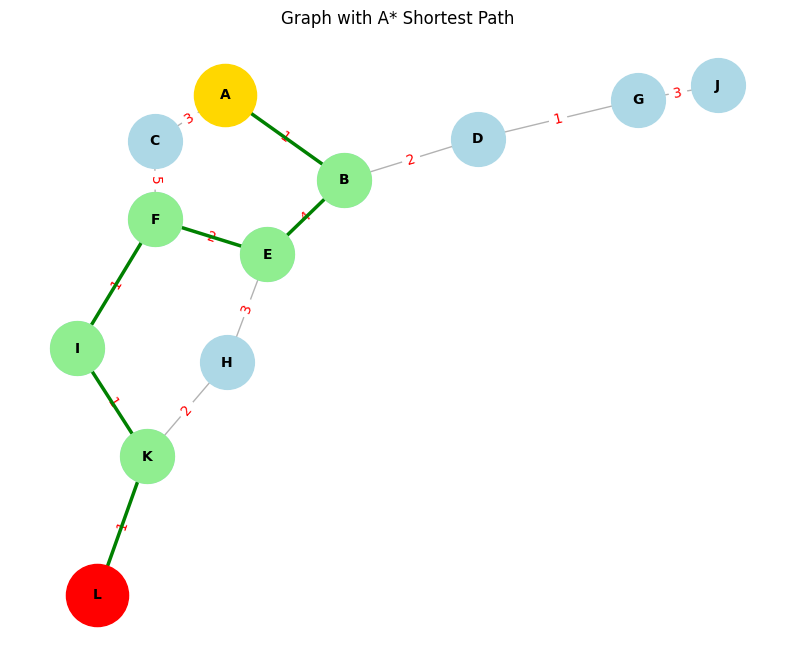

In [4]:
G = nx.Graph()

G.add_nodes_from(graph.keys())

edge_labels = {}
for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)
        edge_labels[(node, neighbor)] = weight

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1500)

nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.6, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

if path:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='green', width=2.5)
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='lightgreen', node_size=1500)

    nx.draw_networkx_nodes(G, pos, nodelist=[start_node], node_color='gold', node_size=2000)
    nx.draw_networkx_nodes(G, pos, nodelist=[goal_node], node_color='red', node_size=2000)

plt.title("Graph with A* Shortest Path")
plt.axis('off')
plt.show()